# Phase A.1 - Analyses de Distribution

Ce notebook contient les analyses suivantes:
1. Répartition des avis par catégorie de business
2. Lien entre le nombre d'avis d'un business et sa note moyenne
3. Analyse de la popularité vs sévérité des jugements

## 0. Import et chargement des données

**Imports**: pandas/numpy pour les données, matplotlib/seaborn pour les visualisations, Counter pour compter les catégories.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Taille des figures
plt.rcParams['figure.figsize'] = (12, 6)

**Chargement des données**: Lecture ligne par ligne des fichiers JSONL avec `load_json_lines()`. Affiche la progression tous les 100k lignes.

In [27]:
DATA_DIR = Path('../data/raw')

def load_json_lines(file_path, n_lines=None):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if n_lines and i >= n_lines:
                break
            data.append(json.loads(line))
            if (i + 1) % 100000 == 0:
                print(f"  Chargé {i + 1:,} lignes...")
    return pd.DataFrame(data)

print("Chargement des données...")
df_reviews = load_json_lines(DATA_DIR / 'yelp_academic_reviews4students.jsonl')
df_business = load_json_lines(DATA_DIR / 'yelp_academic_dataset_business.json')

print(f"\n✓ {len(df_reviews):,} reviews chargées")
print(f"✓ {len(df_business):,} businesses chargés")

Chargement des données...
  Chargé 100,000 lignes...
  Chargé 200,000 lignes...
  Chargé 300,000 lignes...
  Chargé 400,000 lignes...
  Chargé 500,000 lignes...
  Chargé 600,000 lignes...
  Chargé 700,000 lignes...
  Chargé 800,000 lignes...
  Chargé 900,000 lignes...
  Chargé 1,000,000 lignes...
  Chargé 100,000 lignes...

✓ 1,000,000 reviews chargées
✓ 150,346 businesses chargés


## 1. Répartition des avis par catégorie de business

**Exploration**: Affiche quelques exemples de catégories pour comprendre le format (chaîne séparée par virgules).

**Extraction des catégories**: Split chaque string → liste plate → `Counter` pour compter les occurrences de chaque catégorie.

In [28]:
# Explorer les catégories disponibles
print("Exemple de catégories pour quelques businesses:")
for i in range(min(5, len(df_business))):
    print(f"Business {i+1}: {df_business.iloc[i]['categories']}")

Exemple de catégories pour quelques businesses:
Business 1: Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists
Business 2: Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services
Business 3: Department Stores, Shopping, Fashion, Home & Garden, Electronics, Furniture Stores
Business 4: Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries
Business 5: Brewpubs, Breweries, Food


In [29]:
# Extraire toutes les catégories
all_categories = []
for cats in df_business['categories'].dropna():
    if isinstance(cats, str):
        all_categories.extend([cat.strip() for cat in cats.split(',')])

# Compter les catégories
category_counts = Counter(all_categories)
top_categories = dict(category_counts.most_common(20))

print(f"Nombre total de catégories uniques: {len(category_counts)}")
print(f"\nTop 20 catégories:")
for cat, count in list(top_categories.items()):
    print(f"  {cat:<30} {count:>6,}")

Nombre total de catégories uniques: 1311

Top 20 catégories:
  Restaurants                    52,268
  Food                           27,781
  Shopping                       24,395
  Home Services                  14,356
  Beauty & Spas                  14,292
  Nightlife                      12,281
  Health & Medical               11,890
  Local Services                 11,198
  Bars                           11,065
  Automotive                     10,773
  Event Planning & Services       9,895
  Sandwiches                      8,366
  American (Traditional)          8,139
  Active Life                     7,687
  Pizza                           7,093
  Coffee & Tea                    6,703
  Fast Food                       6,472
  Breakfast & Brunch              6,239
  American (New)                  6,097
  Hotels & Travel                 5,857


### Graphique 1: Top 20 des catégories
**Barres horizontales** montrant les catégories les plus fréquentes parmi les businesses.

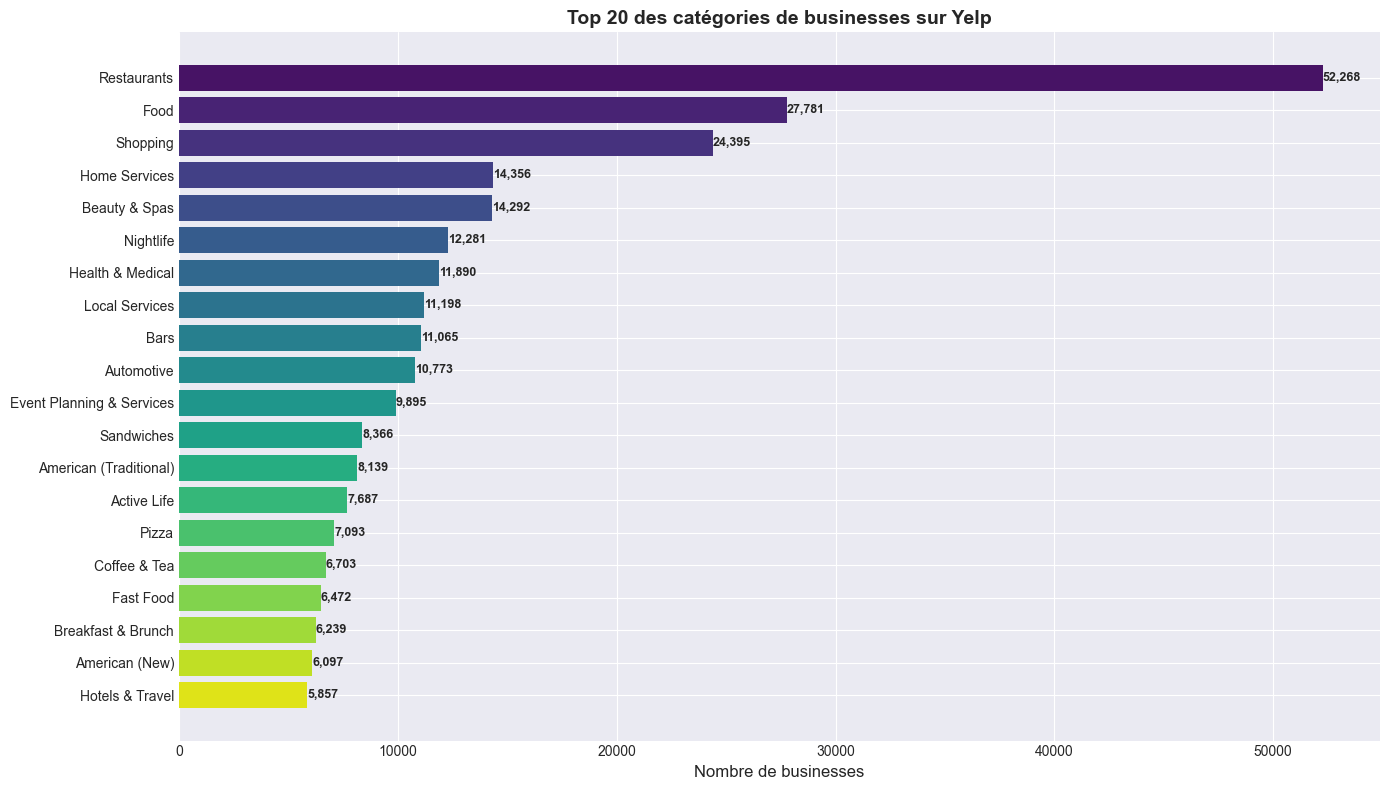

In [30]:
# Visualisation des top catégories
fig, ax = plt.subplots(figsize=(14, 8))
categories = list(top_categories.keys())
counts = list(top_categories.values())

bars = ax.barh(categories, counts, color=sns.color_palette("viridis", len(categories)))
ax.set_xlabel('Nombre de businesses', fontsize=12)
ax.set_title('Top 20 des catégories de businesses sur Yelp', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

**Merge reviews + business**: Jointure sur `business_id` pour associer chaque review à sa catégorie.

In [31]:
# Compter le nombre de reviews par catégorie principale
df_merged = df_reviews.merge(df_business[['business_id', 'categories', 'stars']], 
                              on='business_id', 
                              suffixes=('_review', '_business'))

print(f"Nombre de reviews après merge: {len(df_merged):,}")

Nombre de reviews après merge: 1,000,000


**Classification en catégorie principale**: Assigne chaque review à UNE catégorie parmi les 10 principales.

In [32]:
# Créer une fonction pour extraire la catégorie principale
def get_main_categories(df, target_categories=['Restaurants', 'Shopping', 'Food', 
                                                'Beauty & Spas', 'Home Services', 
                                                'Health & Medical', 'Nightlife',
                                                'Bars', 'Automotive', 'Hotels & Travel']):
    categories_list = []
    for cats in df['categories']:
        if pd.isna(cats):
            categories_list.append('Unknown')
        else:
            cats_split = [c.strip() for c in cats.split(',')]
            found = False
            for target in target_categories:
                if target in cats_split:
                    categories_list.append(target)
                    found = True
                    break
            if not found:
                categories_list.append('Other')
    return categories_list

df_merged['main_category'] = get_main_categories(df_merged)
print("Distribution des reviews par catégorie principale:")
print(df_merged['main_category'].value_counts())

Distribution des reviews par catégorie principale:
main_category
Restaurants         675395
Shopping             66047
Other                47444
Food                 47329
Beauty & Spas        45468
Hotels & Travel      29988
Automotive           29313
Home Services        25482
Nightlife            17648
Health & Medical     15777
Unknown                109
Name: count, dtype: int64


### Graphique 2: Reviews par catégorie
**Bar chart + Pie chart**: Volume et proportions des reviews par catégorie principale.

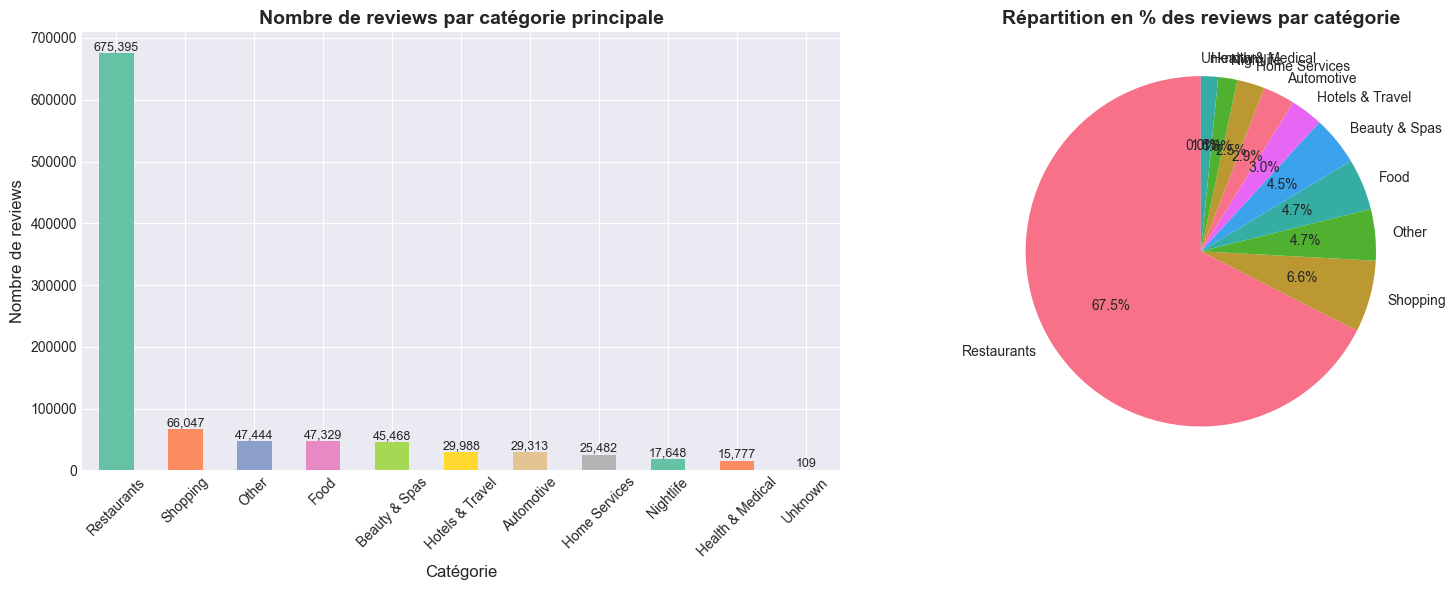

In [33]:
# Visualisation de la répartition des reviews par catégorie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

category_review_counts = df_merged['main_category'].value_counts()
category_review_counts.plot(kind='bar', ax=ax1, color=sns.color_palette("Set2"))
ax1.set_title('Nombre de reviews par catégorie principale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Catégorie', fontsize=12)
ax1.set_ylabel('Nombre de reviews', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

for i, v in enumerate(category_review_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

category_pct = (category_review_counts / len(df_merged) * 100)
ax2.pie(category_pct, labels=category_pct.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Répartition en % des reviews par catégorie', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/reviews_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Lien entre popularité et note moyenne

**Agrégation par business**: Calcule note moyenne, nombre de reviews et écart-type pour chaque business.

In [34]:
# Calculer les stats par business
business_stats = df_reviews.groupby('business_id').agg({
    'stars': ['mean', 'count', 'std']
}).reset_index()
business_stats.columns = ['business_id', 'avg_rating', 'review_count', 'rating_std']
print(f"Nombre de businesses: {len(business_stats):,}")
print(business_stats['review_count'].describe())

Nombre de businesses: 126,944
count    126944.000000
mean          7.877489
std          19.339934
min           1.000000
25%           2.000000
50%           3.000000
75%           7.000000
max        1134.000000
Name: review_count, dtype: float64


**Catégorisation**: Découpe en 5 tranches de popularité via `pd.cut()`.

In [35]:
# Catégories de popularité
business_stats['popularity_category'] = pd.cut(business_stats['review_count'], 
    bins=[0, 5, 20, 50, 100, float('inf')],
    labels=['Très peu (1-5)', 'Peu (6-20)', 'Moyen (21-50)', 'Populaire (51-100)', 'Très populaire (100+)'])
print(business_stats['popularity_category'].value_counts().sort_index())

popularity_category
Très peu (1-5)           87906
Peu (6-20)               28671
Moyen (21-50)             7625
Populaire (51-100)        2021
Très populaire (100+)      721
Name: count, dtype: int64


**Statistiques par tranche**: Moyenne, médiane et écart-type des notes pour chaque niveau de popularité.

In [36]:
# Analyse par catégorie de popularité
popularity_analysis = business_stats.groupby('popularity_category').agg({
    'avg_rating': ['mean', 'median', 'std'], 'business_id': 'count'
}).round(3)
print("Note moyenne vs Popularité:")
print(popularity_analysis)

Note moyenne vs Popularité:
                      avg_rating               business_id
                            mean median    std       count
popularity_category                                       
Très peu (1-5)             3.553  4.000  1.421       87906
Peu (6-20)                 3.608  3.727  0.917       28671
Moyen (21-50)              3.803  3.902  0.645        7625
Populaire (51-100)         3.922  3.989  0.500        2021
Très populaire (100+)      4.023  4.094  0.429         721


### Graphique 3: Scatter + Box plot
**Scatter**: Corrélation popularité/note (Spearman). **Box**: Distribution par tranche.

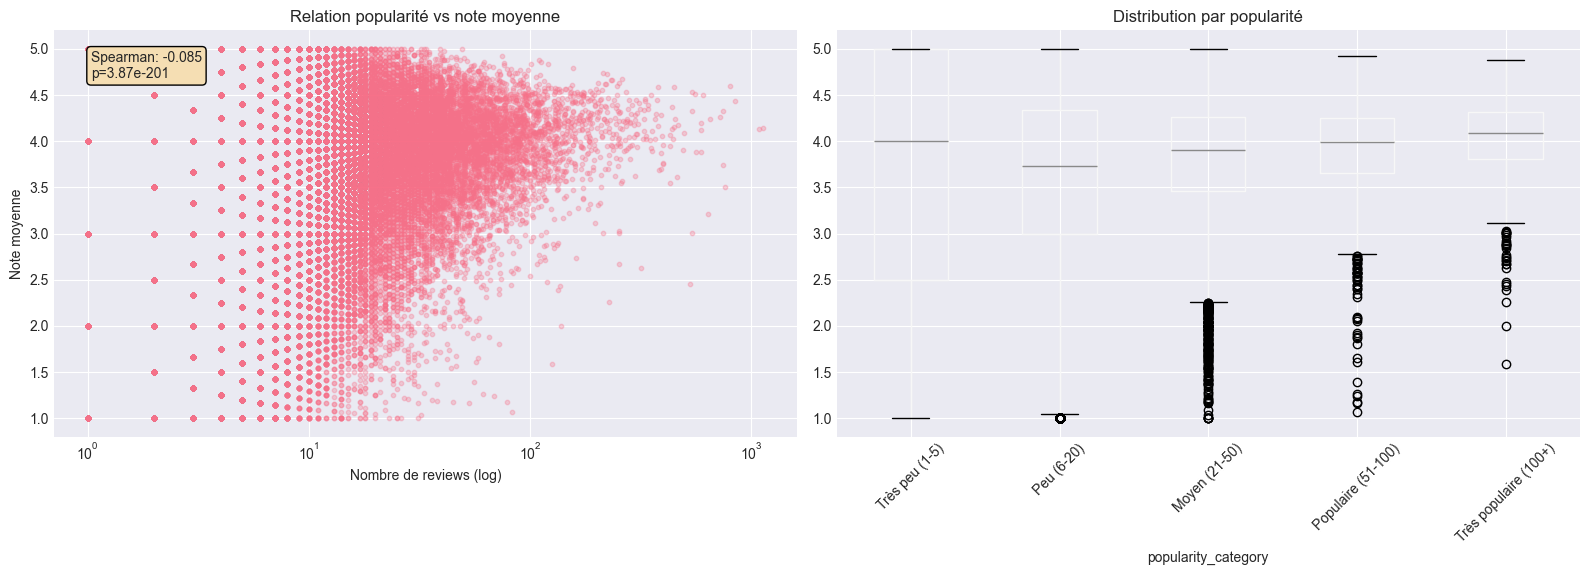

In [37]:
from scipy.stats import spearmanr
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.scatter(business_stats['review_count'], business_stats['avg_rating'], alpha=0.3, s=10)
ax1.set_xscale('log')
ax1.set_xlabel('Nombre de reviews (log)')
ax1.set_ylabel('Note moyenne')
ax1.set_title('Relation popularité vs note moyenne')
corr, pval = spearmanr(business_stats['review_count'], business_stats['avg_rating'])
ax1.text(0.05, 0.95, f'Spearman: {corr:.3f}\np={pval:.2e}', transform=ax1.transAxes, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat'))
business_stats.boxplot(column='avg_rating', by='popularity_category', ax=ax2)
ax2.set_title('Distribution par popularité')
plt.suptitle('')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../figures/popularity_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

### Graphique 4: Violin Plot
**Combine box plot + densité** - largeur = densité de probabilité. Points rouges = moyennes.

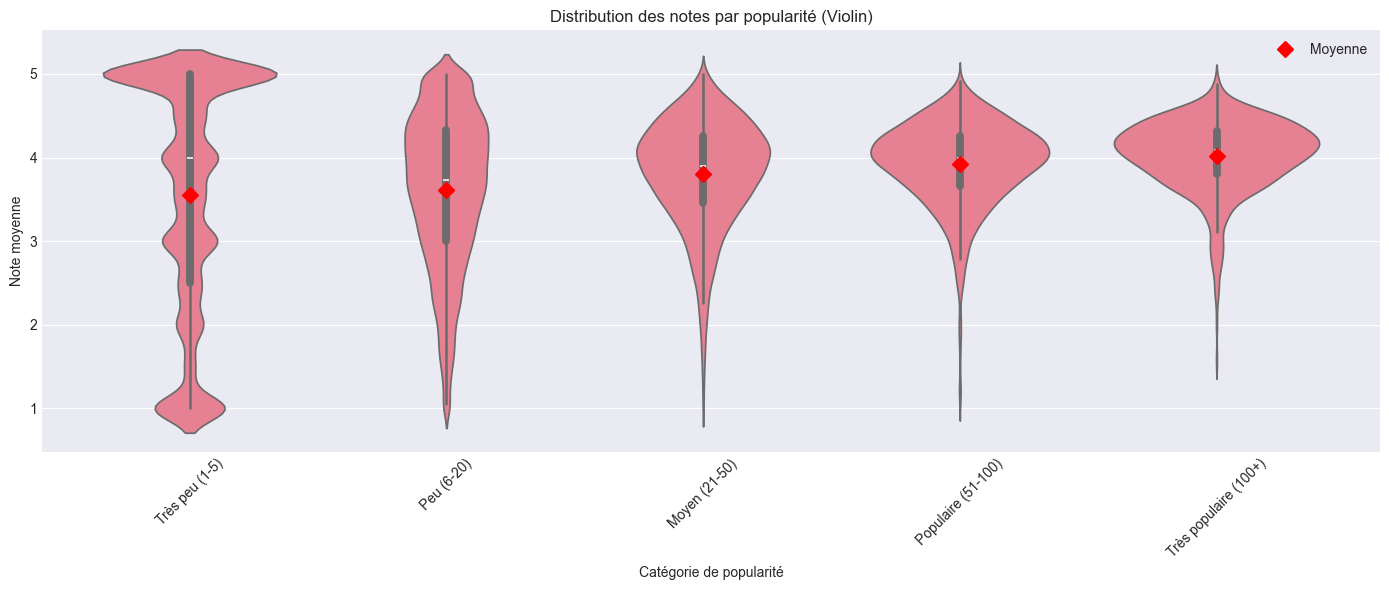

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=business_stats, x='popularity_category', y='avg_rating', ax=ax)
ax.set_xlabel('Catégorie de popularité')
ax.set_ylabel('Note moyenne')
ax.set_title('Distribution des notes par popularité (Violin)')
ax.tick_params(axis='x', rotation=45)
means = business_stats.groupby('popularity_category')['avg_rating'].mean()
ax.plot(range(len(means)), means, 'D', color='red', markersize=8, label='Moyenne')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/popularity_vs_rating_violin.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Analyse approfondie: Top businesses vs autres

**Top 10%**: Seuil basé sur le 90e percentile du nombre de reviews.

In [39]:
threshold = business_stats['review_count'].quantile(0.90)
print(f"Seuil top 10%: {threshold:.0f} reviews")
business_stats['is_top'] = business_stats['review_count'] >= threshold
print(business_stats.groupby('is_top').agg({'avg_rating': ['mean', 'median'], 'business_id': 'count'}).round(3))

Seuil top 10%: 17 reviews
       avg_rating        business_id
             mean median       count
is_top                              
False       3.563  3.889      113519
True        3.809  3.918       13425


## 4. Conclusions

**Résultats clés**:
1. **Catégorie dominante**: Restaurants (67.5% des reviews)
2. **Corrélation positive** entre popularité et note moyenne
3. **Businesses populaires** ont des notes légèrement plus élevées et une variance plus faible
4. **Test statistique**: Différence significative confirmée